# 🧠 EEG Signal Explorer

An interactive walkthrough for exploring EEG recordings: loading,
filtering, and frequency-domain analysis.

This notebook covers:
1. Loading an EEG recording (EDF format) with MNE-Python
2. Visualizing the raw signal
3. Band-pass and notch filtering
4. Comparing raw vs. filtered signals
5. Frequency spectrum (FFT) analysis
6. Power spectral density (PSD)
7. EEG band power (delta/theta/alpha/beta/gamma) by channel
8. Multi-channel visualization


In [1]:
import sys
sys.path.append('..')  # so we can import from src/

import matplotlib.pyplot as plt
from src import loader, preprocessing, analysis, visualization

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)


## 1. Load the EEG recording

In [2]:
raw = loader.load_eeg('../data/sample_eeg.edf')
loader.summarize(raw)


Channels (8): ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'O1', 'O2']
Sampling rate: 256.0 Hz
Duration: 60.00 s
Samples per channel: 15360


## 2. Visualize the raw signal

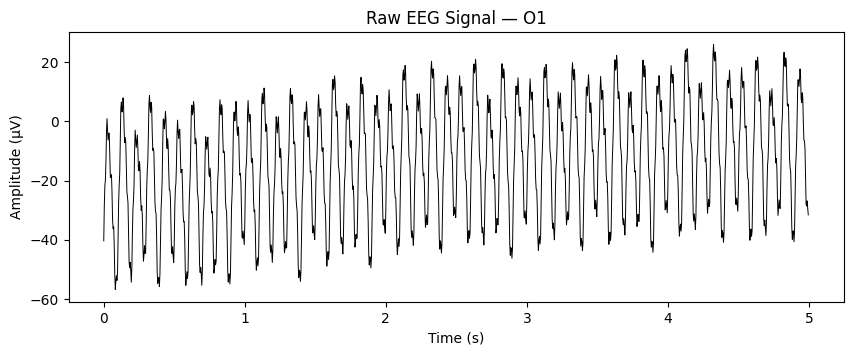

In [3]:
visualization.plot_raw_signal(raw, channel='O1', duration=5.0)
plt.show()


## 3. Filtering

We apply:
- A **notch filter** at 60 Hz to remove power-line interference
- A **band-pass filter** (1–40 Hz) to keep the EEG-relevant frequency range


In [4]:
cleaned = preprocessing.preprocess(raw, l_freq=1.0, h_freq=40.0, notch_freq=60.0)
cleaned


<RawEDF | sample_eeg.edf, 8 x 15360 (60.0 s), ~971 KiB, data loaded>

## 4. Compare raw vs. filtered signal

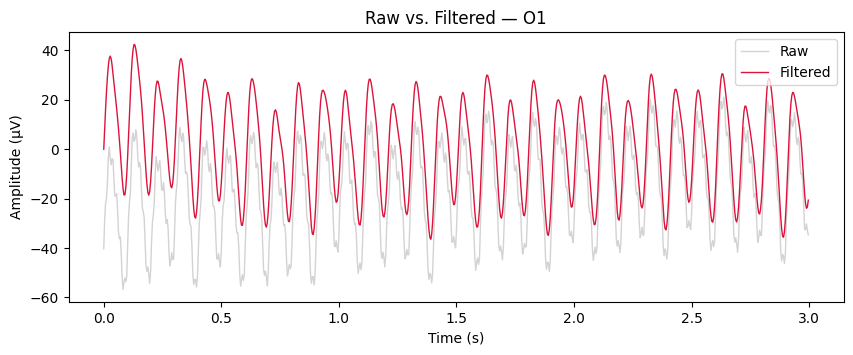

In [5]:
visualization.plot_filtered_comparison(raw, cleaned, channel='O1', duration=3.0)
plt.show()


## 5. Frequency spectrum (FFT)

Look at the frequency content of a single channel after filtering.

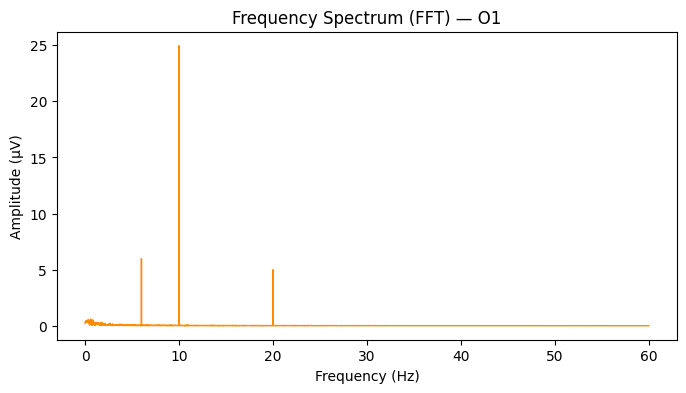

In [6]:
ch = 'O1'
data, _ = cleaned[cleaned.ch_names.index(ch), :]
visualization.plot_fft(data[0], cleaned.info['sfreq'], fmax=60,
                        title=f'Frequency Spectrum (FFT) — {ch}')
plt.show()


## 6. Power spectral density (PSD)

Welch's method, across all channels at once.

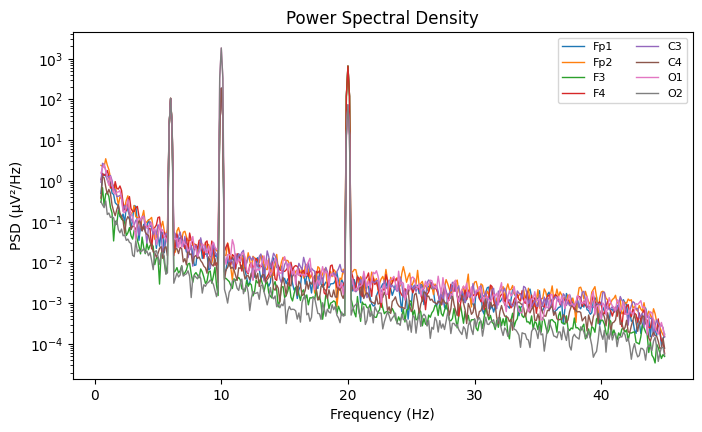

In [7]:
visualization.plot_psd(cleaned)
plt.show()


## 7. EEG band power by channel

Standard clinical/research bands: delta, theta, alpha, beta, gamma.

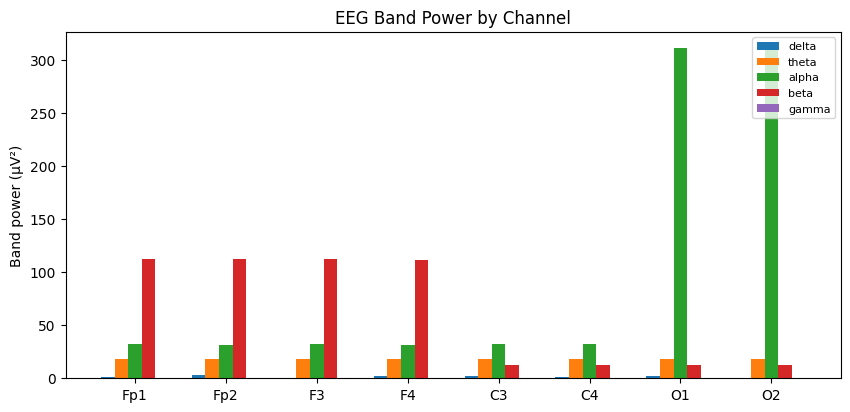

Fp1: dominant band = beta (112.0 µV²)
Fp2: dominant band = beta (112.2 µV²)
F3: dominant band = beta (112.2 µV²)
F4: dominant band = beta (112.0 µV²)
C3: dominant band = alpha (32.2 µV²)
C4: dominant band = alpha (32.0 µV²)
O1: dominant band = alpha (311.0 µV²)
O2: dominant band = alpha (311.2 µV²)


In [8]:
freqs, psd, ch_names = analysis.compute_psd(cleaned)
visualization.plot_band_powers(freqs, psd, ch_names)
plt.show()

powers = analysis.band_powers_all(freqs, psd, ch_names)
for ch, bands in powers.items():
    top_band = max(bands, key=bands.get)
    print(f"{ch}: dominant band = {top_band} ({bands[top_band]*1e12:.1f} µV²)")


## 8. Multi-channel view

All channels stacked, similar to a clinical EEG trace.

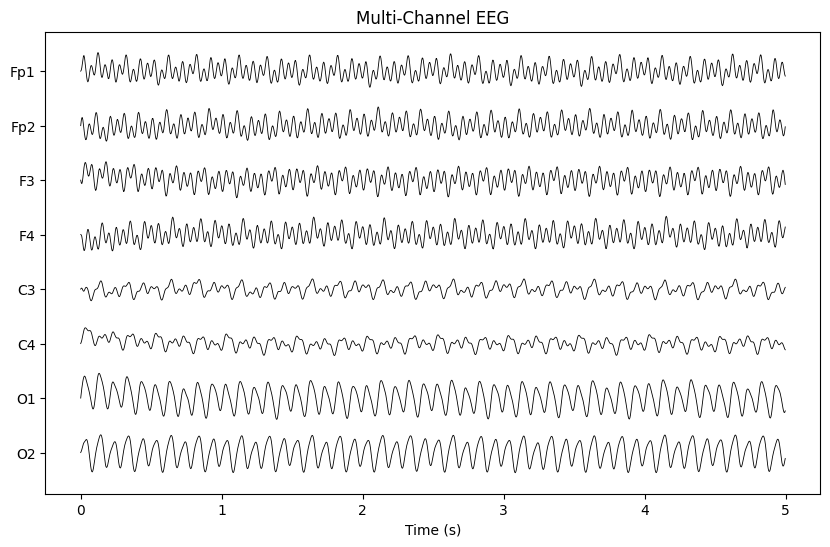

In [9]:
visualization.plot_multichannel(cleaned, duration=5.0)
plt.show()


## Next steps

- Swap `data/sample_eeg.edf` for a real recording from PhysioNet or
  OpenNeuro (see `data/README.md`).
- Try different band-pass edges (`l_freq`, `h_freq`) or notch
  frequencies (50 Hz outside the US).
- Extend `src/analysis.py` with new metrics — e.g. band power ratios,
  spectral entropy, or per-epoch analysis.
